In [109]:
# ============================================================
# Cell 1: Install & Import Dependencies
# ============================================================
import subprocess, sys
for pkg in ['pandas', 'numpy', 'matplotlib', 'seaborn', 'scikit-learn', 'xgboost', 'imbalanced-learn']:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import warnings, glob, os
from pathlib import Path

from sklearn.model_selection import TimeSeriesSplit, cross_val_score, StratifiedShuffleSplit
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             classification_report, confusion_matrix, accuracy_score,
                             f1_score, ConfusionMatrixDisplay)
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
print("All imports loaded successfully!")

All imports loaded successfully!


## 1. Load All Training Scenarios (S1–S10)

In [110]:
# ============================================================
# Cell 2: Load all S1–S10 training CSVs
# ============================================================
TRAINING_DIR = Path('.')  # notebook lives inside data/training/

files = sorted(TRAINING_DIR.glob('S*_v4.csv'))
print(f"Found {len(files)} training files:")
for f in files:
    print(f"  • {f.name}")

dfs = []
for f in files:
    tmp = pd.read_csv(f)
    # Extract scenario code from filename (e.g. S1, S2, ... S10)
    scenario = f.stem.split('_')[0]
    tmp['scenario'] = scenario
    dfs.append(tmp)

df = pd.concat(dfs, ignore_index=True)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values(['scenario', 'timestamp']).reset_index(drop=True)

print(f"\nCombined dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")

print(f"Scenarios: {df['scenario'].unique().tolist()}")
print(f"Target classes: {df['recommended_action'].value_counts().to_dict()}")
df.head()

Found 11 training files:
  • S10_confounded_background_load_v4.csv
  • S13_low_priority_screening_mode_v4.csv
  • S1_high_energy_continuous_supervision_v4.csv
  • S2_low_energy_deferred_batch_v4.csv
  • S3_frequent_short_scans_v4.csv
  • S4_live_view_left_on_monitoring_v4.csv
  • S5_large_area_batch_reconstruction_v4.csv
  • S6_critical_live_view_supervision_v4.csv
  • S7_high_overlap_required_quality_v4.csv
  • S8_post_acquisition_reconstruction_only_v4.csv
  • S9_post_experiment_idle_waste_v4.csv

Combined dataset: 35,717 rows × 30 columns
Scenarios: ['S1', 'S10', 'S13', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9']
Target classes: {'no_action': 23661, 'pause_live_view': 5102, 'optimize_tile_scan_settings': 3707}


,session_id,timestamp,sample_interval_sec,workflow_block_id,workflow_phase,experiment_type,quality_constraint,experiment_running_flag,monitoring_required_flag,live_view_enabled_flag,...,perf_cpu_pct,perf_gpu_usage_pct,perf_gpu_power_w,perf_disk_write_mb_s,perf_incoming_data_mb_s,processing_items_in_flight,estimated_system_power_w,estimated_energy_wh_interval,recommended_action,scenario
0,Z6G4_S1_001,2026-03-22 14:58:09,15,1,tile_scan_acquisition,tile_scan,high,True,True,True,...,11.259,49.979,45.278,34.899,29.601,0.430,255.735,1.06556,optimize_tile_scan_settings,S1
1,Z6G4_S1_001,2026-03-22 14:58:24,15,1,tile_scan_acquisition,tile_scan,high,True,True,True,...,10.980,37.175,43.891,30.609,30.086,0.184,270.003,1.12501,optimize_tile_scan_settings,S1
2,Z6G4_S1_001,2026-03-22 14:58:39,15,1,tile_scan_acquisition,tile_scan,high,True,True,True,...,11.424,33.487,42.041,31.285,33.850,0.905,260.075,1.08365,optimize_tile_scan_settings,S1
3,Z6G4_S1_001,2026-03-22 14:58:54,15,1,tile_scan_acquisition,tile_scan,high,True,True,True,...,11.268,43.057,45.943,25.358,28.668,0.000,266.895,1.11206,optimize_tile_scan_settings,S1
4,Z6G4_S1_001,2026-03-22 14:59:09,15,1,tile_scan_acquisition,tile_scan,high,True,True,True,...,11.413,37.206,44.354,30.751,32.483,0.276,265.915,1.10798,optimize_tile_scan_settings,S1


## 2. Exploratory Data Analysis (EDA)

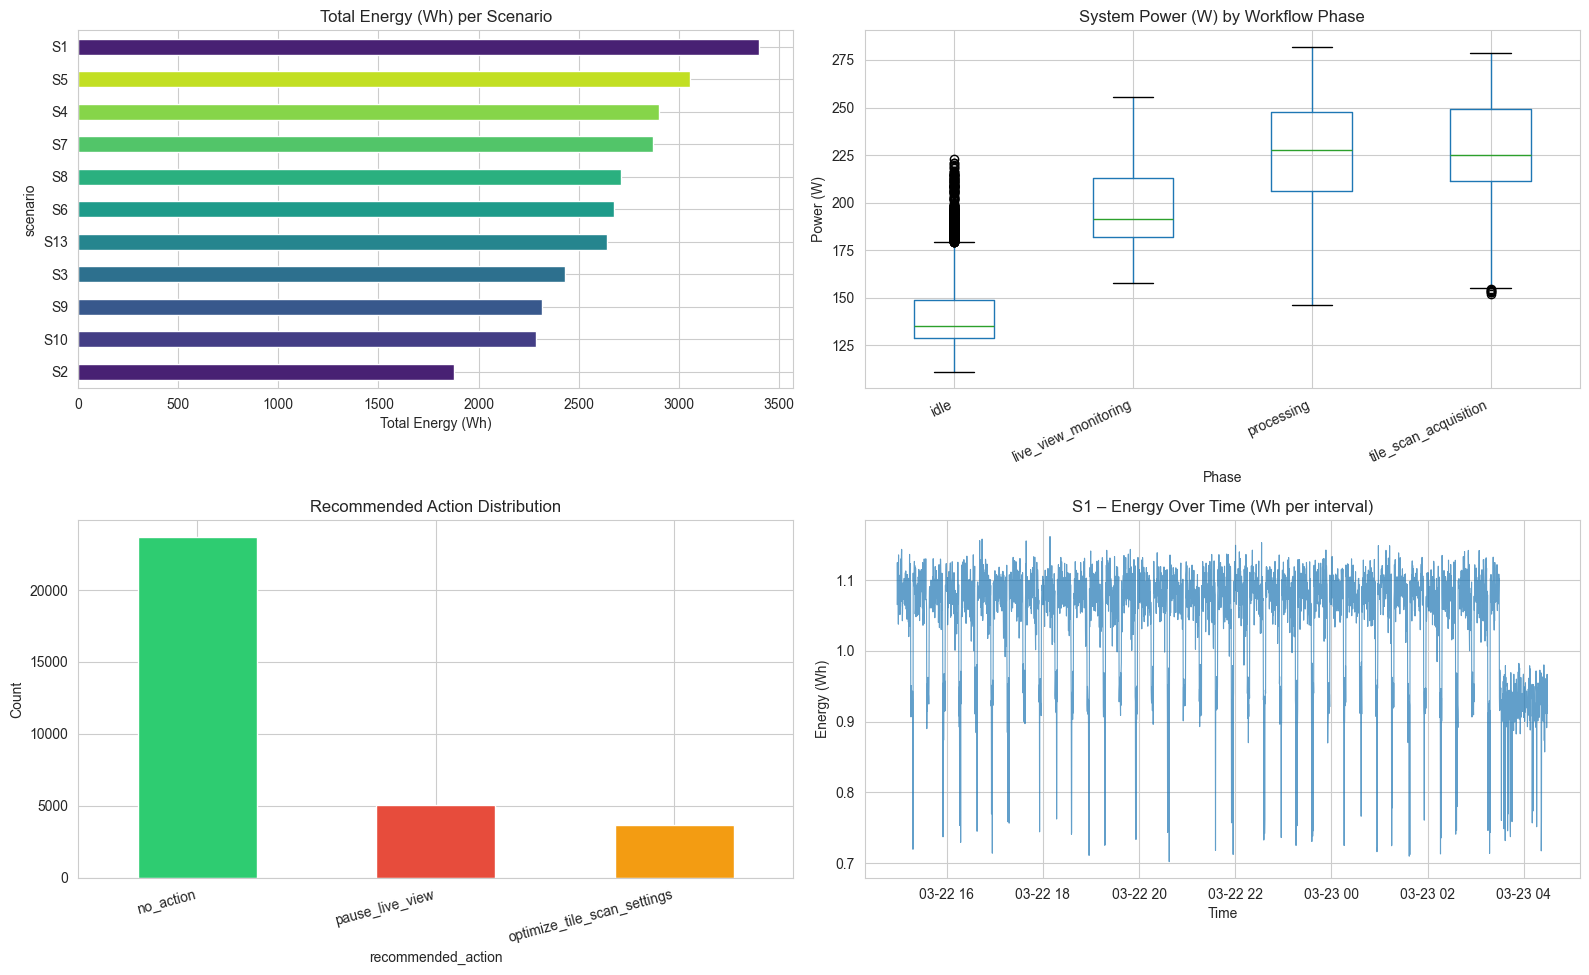


📊 Dataset Summary:
       estimated_system_power_w  estimated_energy_wh_interval  perf_cpu_pct  \
count                  35717.00                      35717.00      35717.00   
mean                     196.05                          0.82         10.47   
std                       42.77                          0.18          7.43   
min                      111.08                          0.46          0.20   
25%                      158.80                          0.66          5.36   
50%                      203.96                          0.85          8.94   
75%                      227.30                          0.95         14.25   
max                      281.98                          1.17         42.45   

       perf_gpu_usage_pct  perf_gpu_power_w  
count            35717.00          35717.00  
mean                28.64             39.97  
std                 16.40             12.34  
min                  0.50             12.33  
25%                 14.51             

In [111]:
# ============================================================
# Cell 3: EDA – Energy distribution per scenario & phase
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 3a. Energy per scenario
ax = axes[0, 0]
df.groupby('scenario')['estimated_energy_wh_interval'].sum().sort_values().plot(
    kind='barh', ax=ax, color=sns.color_palette('viridis', 10))
ax.set_title('Total Energy (Wh) per Scenario')
ax.set_xlabel('Total Energy (Wh)')

# 3b. Power distribution per phase
ax = axes[0, 1]
df.boxplot(column='estimated_system_power_w', by='workflow_phase', ax=ax)
ax.set_title('System Power (W) by Workflow Phase')
ax.set_xlabel('Phase')
ax.set_ylabel('Power (W)')
plt.sca(ax); plt.xticks(rotation=25, ha='right')

# 3c. Action class distribution
ax = axes[1, 0]
df['recommended_action'].value_counts().plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c', '#f39c12'])
ax.set_title('Recommended Action Distribution')
ax.set_ylabel('Count')
plt.sca(ax); plt.xticks(rotation=15, ha='right')

# 3d. Energy over time for one scenario
ax = axes[1, 1]
s1 = df[df['scenario'] == 'S1']
ax.plot(s1['timestamp'], s1['estimated_energy_wh_interval'], alpha=0.7, linewidth=0.8)
ax.set_title('S1 – Energy Over Time (Wh per interval)')
ax.set_xlabel('Time')
ax.set_ylabel('Energy (Wh)')

plt.suptitle('', y=1.0)
plt.tight_layout()
plt.show()

# Summary stats
print("\n📊 Dataset Summary:")
print(df[['estimated_system_power_w', 'estimated_energy_wh_interval',
           'perf_cpu_pct', 'perf_gpu_usage_pct', 'perf_gpu_power_w']].describe().round(2))

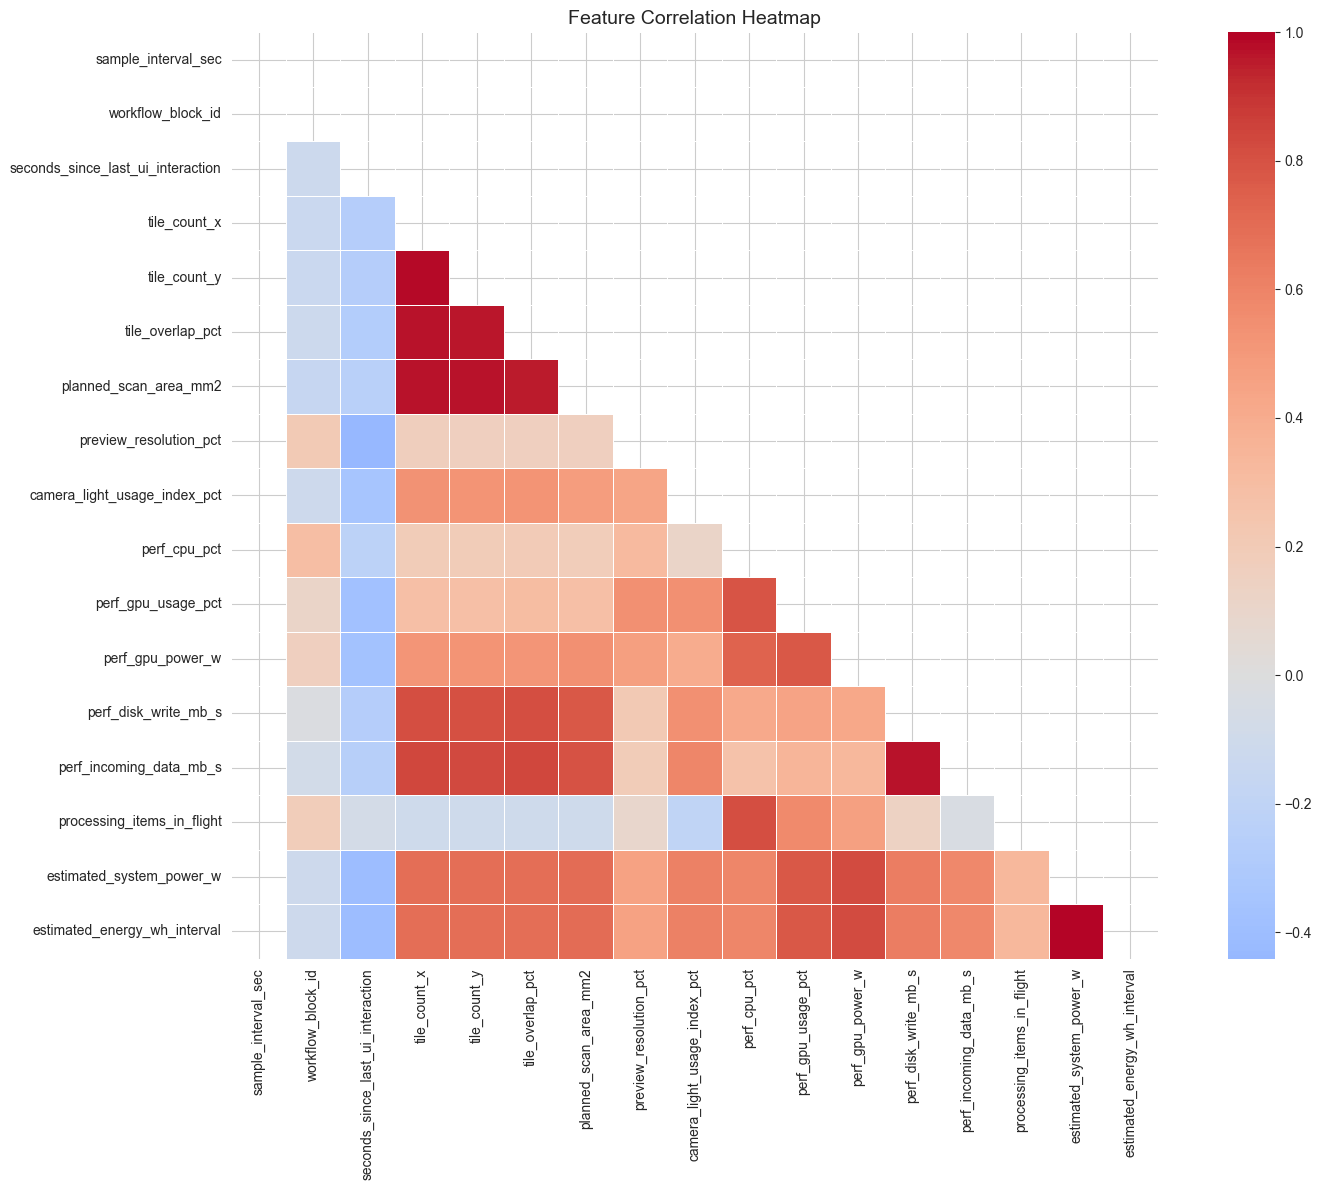

Top 10 features correlated with energy consumption:
estimated_system_power_w        1.0000
perf_gpu_power_w                0.8229
perf_gpu_usage_pct              0.7787
planned_scan_area_mm2           0.7004
tile_count_y                    0.6885
tile_count_x                    0.6877
tile_overlap_pct                0.6864
perf_disk_write_mb_s            0.6336
camera_light_usage_index_pct    0.6078
perf_cpu_pct                    0.5874
Name: estimated_energy_wh_interval, dtype: float64


In [112]:
# ============================================================
# Cell 4: Correlation heatmap for numeric features
# ============================================================
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

# Top correlations with energy target
target_corr = corr['estimated_energy_wh_interval'].drop('estimated_energy_wh_interval').abs().sort_values(ascending=False)
print("Top 10 features correlated with energy consumption:")
print(target_corr.head(10).round(4))

## 3. Feature Engineering (Rob Mulla Style)
Time-based features, lag features, rolling window statistics, and domain-specific interaction features.

In [113]:
# ============================================================
# Cell 5: Feature Engineering
# ============================================================

def create_features(data):
    """Create time-series & domain features for each scenario group."""
    data = data.copy()
    
    # --- 1. TIME-BASED FEATURES (Rob Mulla style) ---
    data['hour'] = data['timestamp'].dt.hour
    data['minute'] = data['timestamp'].dt.minute
    data['dayofweek'] = data['timestamp'].dt.dayofweek
    data['elapsed_sec'] = (data['timestamp'] - data['timestamp'].iloc[0]).dt.total_seconds()
    
    # --- 2. ENCODE CATEGORICALS ---
    phase_map = {'idle': 0, 'processing': 1, 'live_view_monitoring': 2, 'tile_scan_acquisition': 3}
    data['phase_encoded'] = data['workflow_phase'].map(phase_map).fillna(-1).astype(int)
    
    exp_map = {'none': 0, 'alignment_check': 1, 'overview_scan': 2, 'tile_scan': 3,
               'time_lapse': 4, 'reconstruction_only': 5}
    data['experiment_encoded'] = data['experiment_type'].map(exp_map).fillna(-1).astype(int)
    
    qual_map = {'low': 0, 'medium': 1, 'high': 2}
    data['quality_encoded'] = data['quality_constraint'].map(qual_map).fillna(-1).astype(int)
    
    # --- 3. LAG FEATURES (energy & power) ---
    for lag in [1, 2, 3, 5, 10]:
        data[f'energy_lag_{lag}'] = data['estimated_energy_wh_interval'].shift(lag)
        data[f'power_lag_{lag}'] = data['estimated_system_power_w'].shift(lag)
    
    # --- 4. ROLLING WINDOW FEATURES ---
    for window in [5, 10, 20]:
        data[f'energy_roll_mean_{window}'] = data['estimated_energy_wh_interval'].rolling(window).mean()
        data[f'energy_roll_std_{window}'] = data['estimated_energy_wh_interval'].rolling(window).std()
        data[f'power_roll_mean_{window}'] = data['estimated_system_power_w'].rolling(window).mean()
        data[f'power_roll_std_{window}'] = data['estimated_system_power_w'].rolling(window).std()
        data[f'gpu_power_roll_mean_{window}'] = data['perf_gpu_power_w'].rolling(window).mean()
        data[f'cpu_roll_mean_{window}'] = data['perf_cpu_pct'].rolling(window).mean()
    
    # --- 5. DOMAIN-SPECIFIC FEATURES ---
    data['tile_total'] = data['tile_count_x'] * data['tile_count_y']
    data['live_view_waste'] = ((data['live_view_enabled_flag'].astype(int)) & 
                                (data['user_interacting_flag'].astype(int) == 0)).astype(int)
    data['high_inactivity'] = (data['seconds_since_last_ui_interaction'] > 120).astype(int)
    data['power_gpu_ratio'] = np.where(data['perf_gpu_power_w'] > 0,
                                        data['estimated_system_power_w'] / data['perf_gpu_power_w'], 0)
    data['total_data_throughput'] = data['perf_disk_write_mb_s'] + data['perf_incoming_data_mb_s']
    data['energy_delta'] = data['estimated_energy_wh_interval'].diff()
    data['power_delta'] = data['estimated_system_power_w'].diff()
    data['phase_change'] = (data['workflow_phase'] != data['workflow_phase'].shift(1)).astype(int)
    data['phase_duration_steps'] = data.groupby(data['phase_change'].cumsum()).cumcount() + 1
    
    return data

# FIX: Use explicit loop instead of groupby().apply() to avoid pandas 2.x
# dropping the groupby key column from the result
feat_dfs = []
for scenario_name, group in df.groupby('scenario'):
    feat = create_features(group.copy())
    feat_dfs.append(feat)

df_feat = pd.concat(feat_dfs, ignore_index=True)
df_feat = df_feat.dropna().reset_index(drop=True)

print(f"Feature-engineered dataset: {df_feat.shape[0]:,} rows × {df_feat.shape[1]} columns")
print(f"New features added: {df_feat.shape[1] - df.shape[1]}")
print(f"Scenarios present: {df_feat['scenario'].unique().tolist()}")
df_feat.head()

Feature-engineered dataset: 32,280 rows × 74 columns
New features added: 44
Scenarios present: ['S1', 'S10', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9']


,session_id,timestamp,sample_interval_sec,workflow_block_id,workflow_phase,experiment_type,quality_constraint,experiment_running_flag,monitoring_required_flag,live_view_enabled_flag,...,cpu_roll_mean_20,tile_total,live_view_waste,high_inactivity,power_gpu_ratio,total_data_throughput,energy_delta,power_delta,phase_change,phase_duration_steps
0,Z6G4_S1_001,2026-03-22 15:02:54,15,1,tile_scan_acquisition,tile_scan,high,True,True,True,...,11.08225,96,1,0,5.756753,70.052,-0.04324,-10.377,0,20
1,Z6G4_S1_001,2026-03-22 15:03:09,15,1,tile_scan_acquisition,tile_scan,high,True,True,True,...,11.01770,72,1,0,5.656650,52.069,-0.01545,-3.710,0,21
2,Z6G4_S1_001,2026-03-22 15:03:24,15,1,tile_scan_acquisition,tile_scan,high,True,True,True,...,11.00895,80,1,0,5.820082,57.124,0.05836,14.006,0,22
3,Z6G4_S1_001,2026-03-22 15:03:39,15,1,tile_scan_acquisition,tile_scan,high,True,True,True,...,10.97820,90,1,0,5.566365,67.054,0.01390,3.337,0,23
4,Z6G4_S1_001,2026-03-22 15:03:54,15,1,tile_scan_acquisition,tile_scan,high,True,True,True,...,11.02415,80,1,1,5.785509,56.181,-0.00080,-0.192,0,24


## 4. Model 1 – XGBoost Energy Regression
Predict `estimated_energy_wh_interval` using Leave-One-Scenario-Out CV, then train final model on ALL S1-S10.

In [114]:
# ============================================================
# Cell 6: Prepare features & splits
# ============================================================
# STRATEGY:
#   1. S1-S7 train / S8-S10 eval  → for evaluation & visualization
#   2. ALL S1-S10                  → final model for deployment to S13
#
# Why train on ALL S1-S10?
#   - S8 teaches post-acquisition patterns (reconstruction only)
#   - S9 teaches idle waste patterns
#   - S10 teaches noise separation
#   Training on only 7/10 scenarios leaves the model blind
#   to 30% of the behaviour diversity.
# ============================================================

EXCLUDE_COLS = ['session_id', 'timestamp', 'workflow_phase', 'experiment_type',
                'quality_constraint', 'recommended_action', 'scenario',
                'estimated_energy_wh_interval',  # target
                'phase_change']

FEATURE_COLS = [c for c in df_feat.columns if c not in EXCLUDE_COLS]

ENERGY_TARGET = 'estimated_energy_wh_interval'
ACTION_TARGET = 'recommended_action'

print(f"Number of features: {len(FEATURE_COLS)}")
print(f"Features (first 15): {FEATURE_COLS[:15]} ...")

# ── Full arrays (ALL S1-S10) for final model ──
X_all = df_feat[FEATURE_COLS].values
y_energy_all = df_feat[ENERGY_TARGET].values

# ── Scenario-based eval split (for visualization cells) ──
TRAIN_SCENARIOS = ['S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7']
TEST_SCENARIOS  = ['S8', 'S9', 'S10']

train_mask = df_feat['scenario'].isin(TRAIN_SCENARIOS)
test_mask  = df_feat['scenario'].isin(TEST_SCENARIOS)

X_train = df_feat.loc[train_mask, FEATURE_COLS].values
X_test  = df_feat.loc[test_mask,  FEATURE_COLS].values
y_train = df_feat.loc[train_mask, ENERGY_TARGET].values
y_test  = df_feat.loc[test_mask,  ENERGY_TARGET].values

print(f"\nEvaluation split:  S1-S7 ({X_train.shape[0]:,}) → S8-S10 ({X_test.shape[0]:,})")
print(f"Final model data:  ALL S1-S10 ({len(X_all):,} rows)")
print(f"\nScenarios: {sorted(df_feat['scenario'].unique().tolist())}")

Number of features: 65
Features (first 15): ['sample_interval_sec', 'workflow_block_id', 'experiment_running_flag', 'monitoring_required_flag', 'live_view_enabled_flag', 'continuous_acquisition_display_flag', 'tile_scan_enabled_flag', 'user_interacting_flag', 'seconds_since_last_ui_interaction', 'tile_count_x', 'tile_count_y', 'tile_overlap_pct', 'planned_scan_area_mm2', 'preview_resolution_pct', 'camera_light_usage_index_pct'] ...

Evaluation split:  S1-S7 (22,596) → S8-S10 (9,684)
Final model data:  ALL S1-S10 (32,280 rows)

Scenarios: ['S1', 'S10', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9']


In [115]:
# ============================================================
# Cell 7: Train XGBoost Regressor for Energy Prediction
# ============================================================

# ── Step 1: Leave-One-Scenario-Out Cross-Validation ──────────
print("LEAVE-ONE-SCENARIO-OUT CV – Energy Regression")
print("=" * 60)

loso_energy = []
for scen in sorted(df_feat['scenario'].unique()):
    tr = df_feat['scenario'] != scen
    te = df_feat['scenario'] == scen
    reg_cv = xgb.XGBRegressor(
        n_estimators=500, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
        reg_alpha=0.1, reg_lambda=1.0, random_state=42, n_jobs=-1)
    reg_cv.fit(df_feat.loc[tr, FEATURE_COLS].values,
               df_feat.loc[tr, ENERGY_TARGET].values, verbose=False)
    p = reg_cv.predict(df_feat.loc[te, FEATURE_COLS].values)
    r2_cv = r2_score(df_feat.loc[te, ENERGY_TARGET].values, p)
    mae_cv = mean_absolute_error(df_feat.loc[te, ENERGY_TARGET].values, p)
    loso_energy.append({'Scenario': scen, 'R2': round(r2_cv, 4), 'MAE': round(mae_cv, 5)})
    print(f"  Hold-out {scen}: R²={r2_cv:.4f}  MAE={mae_cv:.5f}")

loso_e_df = pd.DataFrame(loso_energy)
print(f"\nLOSO Mean R²:  {loso_e_df['R2'].mean():.4f} ± {loso_e_df['R2'].std():.4f}")
print(f"LOSO Mean MAE: {loso_e_df['MAE'].mean():.5f}")

# ── Step 2: S1-S7 → S8-S10 evaluation (for Cell 8 viz) ──────
reg_eval = xgb.XGBRegressor(
    n_estimators=1000, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
    reg_alpha=0.1, reg_lambda=1.0, random_state=42, n_jobs=-1,
    early_stopping_rounds=50)
reg_eval.fit(X_train, y_train,
             eval_set=[(X_train, y_train), (X_test, y_test)], verbose=100)
best_n_reg = reg_eval.best_iteration if hasattr(reg_eval, 'best_iteration') and reg_eval.best_iteration else 500

y_pred_energy = reg_eval.predict(X_test)
mae = mean_absolute_error(y_test, y_pred_energy)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_energy))
r2 = r2_score(y_test, y_pred_energy)

print(f"\n{'='*55}")
print(f"S1-S7 → S8-S10 Evaluation")
print(f"{'='*55}")
print(f"MAE:  {mae:.5f} Wh")
print(f"RMSE: {rmse:.5f} Wh")
print(f"R²:   {r2:.4f}")
print(f"Best iteration: {best_n_reg}")

# ── Step 3: Train FINAL model on ALL S1-S10 ──────────────────
print(f"\n>>> Training FINAL regressor on ALL S1-S10 ({len(X_all):,} rows) ...")
reg_model = xgb.XGBRegressor(
    n_estimators=best_n_reg, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
    reg_alpha=0.1, reg_lambda=1.0, random_state=42, n_jobs=-1)
reg_model.fit(X_all, y_energy_all, verbose=100)
print("✅ Final energy regressor trained on ALL S1-S10!")

LEAVE-ONE-SCENARIO-OUT CV – Energy Regression
  Hold-out S1: R²=0.9978  MAE=0.00252
  Hold-out S10: R²=0.9975  MAE=0.00372
  Hold-out S2: R²=0.9848  MAE=0.00787
  Hold-out S3: R²=0.9926  MAE=0.00621
  Hold-out S4: R²=0.9968  MAE=0.00179
  Hold-out S5: R²=0.9964  MAE=0.00588
  Hold-out S6: R²=0.9996  MAE=0.00174
  Hold-out S7: R²=0.9996  MAE=0.00286
  Hold-out S8: R²=0.9976  MAE=0.00723
  Hold-out S9: R²=0.9997  MAE=0.00142

LOSO Mean R²:  0.9962 ± 0.0045
LOSO Mean MAE: 0.00412
[0]	validation_0-rmse:0.17090	validation_1-rmse:0.18757
[100]	validation_0-rmse:0.00257	validation_1-rmse:0.00953
[200]	validation_0-rmse:0.00166	validation_1-rmse:0.00821
[300]	validation_0-rmse:0.00148	validation_1-rmse:0.00784
[400]	validation_0-rmse:0.00139	validation_1-rmse:0.00762
[500]	validation_0-rmse:0.00134	validation_1-rmse:0.00751
[600]	validation_0-rmse:0.00132	validation_1-rmse:0.00746
[700]	validation_0-rmse:0.00130	validation_1-rmse:0.00742
[800]	validation_0-rmse:0.00129	validation_1-rmse:0.0074

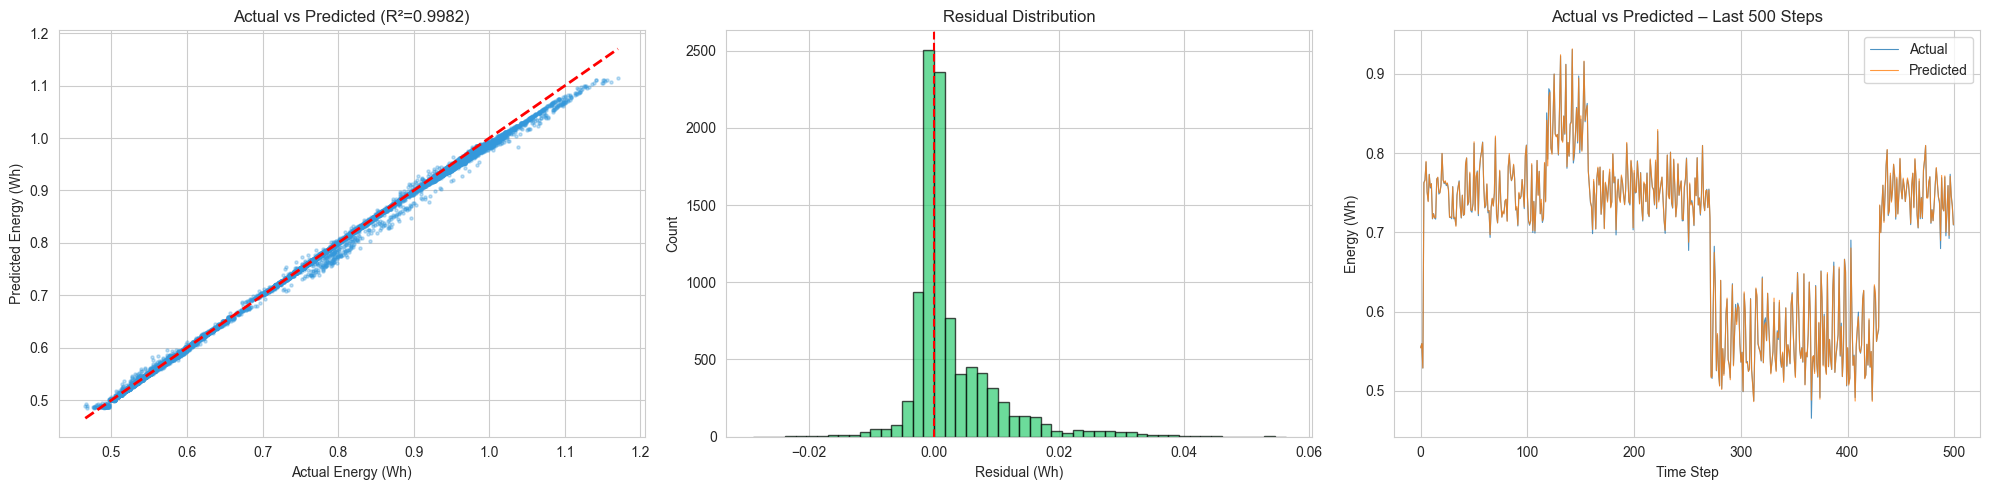

In [116]:
# ============================================================
# Cell 8: Regression – Visualization
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 8a. Actual vs Predicted scatter
ax = axes[0]
ax.scatter(y_test, y_pred_energy, alpha=0.3, s=5, color='#3498db')
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax.set_xlabel('Actual Energy (Wh)')
ax.set_ylabel('Predicted Energy (Wh)')
ax.set_title(f'Actual vs Predicted (R²={r2:.4f})')

# 8b. Residual distribution
ax = axes[1]
residuals = y_test - y_pred_energy
ax.hist(residuals, bins=50, color='#2ecc71', edgecolor='black', alpha=0.7)
ax.axvline(0, color='red', linestyle='--')
ax.set_xlabel('Residual (Wh)')
ax.set_ylabel('Count')
ax.set_title('Residual Distribution')

# 8c. Time series overlay (last 500 points)
ax = axes[2]
n_show = 500
ax.plot(range(n_show), y_test[-n_show:], label='Actual', alpha=0.8, linewidth=0.8)
ax.plot(range(n_show), y_pred_energy[-n_show:], label='Predicted', alpha=0.8, linewidth=0.8)
ax.set_xlabel('Time Step')
ax.set_ylabel('Energy (Wh)')
ax.set_title('Actual vs Predicted – Last 500 Steps')
ax.legend()

plt.tight_layout()
plt.show()

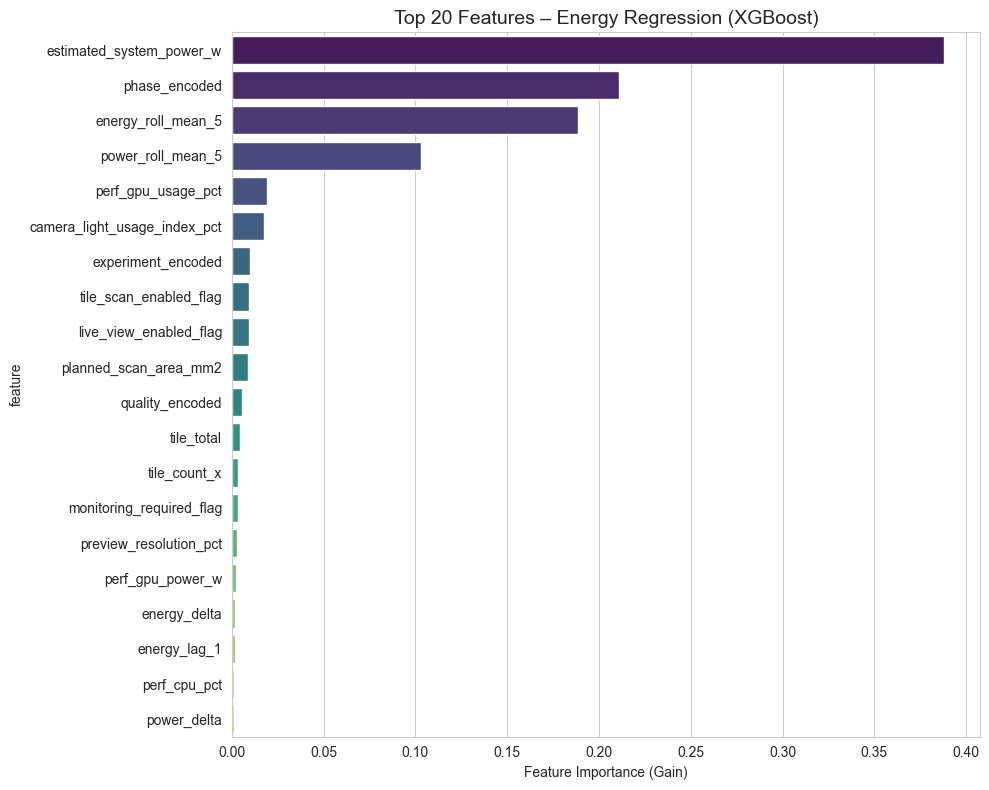

In [117]:
# ============================================================
# Cell 9: Feature Importance (Regression)
# ============================================================
importance = reg_model.feature_importances_
feat_imp = pd.DataFrame({'feature': FEATURE_COLS, 'importance': importance})
feat_imp = feat_imp.sort_values('importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=feat_imp, x='importance', y='feature', palette='viridis', ax=ax)
ax.set_title('Top 20 Features – Energy Regression (XGBoost)', fontsize=14)
ax.set_xlabel('Feature Importance (Gain)')
plt.tight_layout()
plt.show()

## 5. Model 2 – XGBoost Action Classifier

### Why scenario-based split?

| Split method | Result | Why |
|---|---|---|
| **Row split within same scenario** | Overfitting risk | Train & test share the same scenario's temporal patterns |
| **Scenario-based split** | Realistic accuracy | Test scenarios (S8–S10) are completely unseen during training — model must truly generalise |

### Approach
- **Train**: S1–S7 (7 scenarios = 70%)
- **Test**: S8–S10 (3 fully held-out scenarios = 30%)
- **SMOTE**: oversample minority action classes in the training set only
- **Features**: All 65 features (same as energy regressor) — sensor readings like `live_view_enabled_flag`, `tile_overlap_pct` etc. are real-time inputs available at inference

In [118]:
# ============================================================
# Cell 10: Train XGBoost Classifier for Action Prediction
# ============================================================
# Uses ALL 65 features (sensor readings are legitimate inputs).
# Trained on ALL S1-S10 for maximum generalization to S13.
# ─────────────────────────────────────────────────────────────

# Encode target
le = LabelEncoder()
le.fit(df_feat[ACTION_TARGET])
class_names = le.classes_
y_action_all = le.transform(df_feat[ACTION_TARGET])

print(f"Classifier features: {len(FEATURE_COLS)} (all features)")
print(f"\nAction classes: {list(class_names)}")
class_counts = np.bincount(y_action_all)
print(f"Class distribution (full dataset):")
for name, count in zip(class_names, class_counts):
    print(f"  {name:<35}: {count:>6}  ({100*count/len(y_action_all):.1f}%)")

# ── Step 1: Leave-One-Scenario-Out Cross-Validation ──────────
print(f"\nLEAVE-ONE-SCENARIO-OUT CV – Action Classification")
print("=" * 60)

loso_clf = []
all_y_true, all_y_pred = [], []

for scen in sorted(df_feat['scenario'].unique()):
    tr = df_feat['scenario'] != scen
    te = df_feat['scenario'] == scen

    X_tr = df_feat.loc[tr, FEATURE_COLS].values
    X_te = df_feat.loc[te, FEATURE_COLS].values
    y_tr = le.transform(df_feat.loc[tr, ACTION_TARGET])
    y_te = le.transform(df_feat.loc[te, ACTION_TARGET])

    # SMOTE on training fold
    sm = SMOTE(random_state=42)
    X_tr_r, y_tr_r = sm.fit_resample(X_tr, y_tr)

    clf_cv = xgb.XGBClassifier(
        n_estimators=500, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
        reg_alpha=0.1, reg_lambda=1.0,
        objective='multi:softmax', num_class=len(class_names),
        eval_metric='mlogloss', random_state=42, n_jobs=-1)
    clf_cv.fit(X_tr_r, y_tr_r, verbose=False)
    pred = clf_cv.predict(X_te)

    acc_cv = accuracy_score(y_te, pred)
    f1_cv = f1_score(y_te, pred, average='macro', zero_division=0)
    loso_clf.append({'Scenario': scen, 'Accuracy': round(acc_cv, 4), 'F1_macro': round(f1_cv, 4)})
    all_y_true.extend(y_te.tolist())
    all_y_pred.extend(pred.tolist())
    print(f"  Hold-out {scen}: Accuracy={acc_cv:.4f}  F1(macro)={f1_cv:.4f}")

loso_c_df = pd.DataFrame(loso_clf)
print(f"\nLOSO Mean Accuracy: {loso_c_df['Accuracy'].mean():.4f} ± {loso_c_df['Accuracy'].std():.4f}")
print(f"LOSO Mean F1 macro: {loso_c_df['F1_macro'].mean():.4f} ± {loso_c_df['F1_macro'].std():.4f}")
print(f"\nOverall LOSO Classification Report:")
print(classification_report(all_y_true, all_y_pred, target_names=class_names, zero_division=0))

# ── Step 2: S1-S7 → S8-S10 evaluation (for Cell 11 viz) ─────
X_train_cls = df_feat.loc[train_mask, FEATURE_COLS].values
X_test_cls  = df_feat.loc[test_mask,  FEATURE_COLS].values
y_train_cls = le.transform(df_feat.loc[train_mask, ACTION_TARGET])
y_test_cls  = le.transform(df_feat.loc[test_mask,  ACTION_TARGET])

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_cls, y_train_cls)

clf_eval = xgb.XGBClassifier(
    n_estimators=1000, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
    reg_alpha=0.1, reg_lambda=1.0,
    objective='multi:softmax', num_class=len(class_names),
    eval_metric='mlogloss', random_state=42, n_jobs=-1,
    early_stopping_rounds=50)
clf_eval.fit(X_train_res, y_train_res,
             eval_set=[(X_train_res, y_train_res), (X_test_cls, y_test_cls)],
             verbose=100)
best_n_clf = clf_eval.best_iteration if hasattr(clf_eval, 'best_iteration') and clf_eval.best_iteration else 500

y_pred_action = clf_eval.predict(X_test_cls)
acc = accuracy_score(y_test_cls, y_pred_action)
f1_macro = f1_score(y_test_cls, y_pred_action, average='macro')
f1_weighted = f1_score(y_test_cls, y_pred_action, average='weighted')

print(f"\n{'='*55}")
print(f"S1-S7 → S8-S10 Evaluation")
print(f"  Features: {len(FEATURE_COLS)} (all)")
print(f"{'='*55}")
print(f"Accuracy:        {acc:.4f}")
print(f"F1 (macro):      {f1_macro:.4f}")
print(f"F1 (weighted):   {f1_weighted:.4f}")
print(f"\n{classification_report(y_test_cls, y_pred_action, target_names=class_names)}")

# ── Step 3: Train FINAL model on ALL S1-S10 ──────────────────
print(f">>> Training FINAL classifier on ALL S1-S10 ({len(X_all):,} rows) ...")
smote_final = SMOTE(random_state=42)
X_all_res, y_all_res = smote_final.fit_resample(X_all, y_action_all)
print(f"After SMOTE: {len(X_all_res):,} rows")
print(f"Resampled distribution: {dict(zip(class_names, np.bincount(y_all_res)))}")

clf_model = xgb.XGBClassifier(
    n_estimators=best_n_clf, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
    reg_alpha=0.1, reg_lambda=1.0,
    objective='multi:softmax', num_class=len(class_names),
    eval_metric='mlogloss', random_state=42, n_jobs=-1)
clf_model.fit(X_all_res, y_all_res, verbose=100)
print("✅ Final action classifier trained on ALL S1-S10!")

Classifier features: 65 (all features)

Action classes: ['no_action', 'optimize_tile_scan_settings', 'pause_live_view']
Class distribution (full dataset):
  no_action                          :  23523  (72.9%)
  optimize_tile_scan_settings        :   3672  (11.4%)
  pause_live_view                    :   5085  (15.8%)

LEAVE-ONE-SCENARIO-OUT CV – Action Classification
  Hold-out S1: Accuracy=0.9105  F1(macro)=0.9082
  Hold-out S10: Accuracy=0.9997  F1(macro)=0.9997
  Hold-out S2: Accuracy=1.0000  F1(macro)=1.0000
  Hold-out S3: Accuracy=0.9833  F1(macro)=0.7601
  Hold-out S4: Accuracy=0.9975  F1(macro)=0.9973
  Hold-out S5: Accuracy=0.9997  F1(macro)=0.9996
  Hold-out S6: Accuracy=0.9870  F1(macro)=0.3312
  Hold-out S7: Accuracy=0.5074  F1(macro)=0.4455
  Hold-out S8: Accuracy=0.9991  F1(macro)=0.9563
  Hold-out S9: Accuracy=0.9926  F1(macro)=0.6648

LOSO Mean Accuracy: 0.9377 ± 0.1536
LOSO Mean F1 macro: 0.8063 ± 0.2494

Overall LOSO Classification Report:
                            

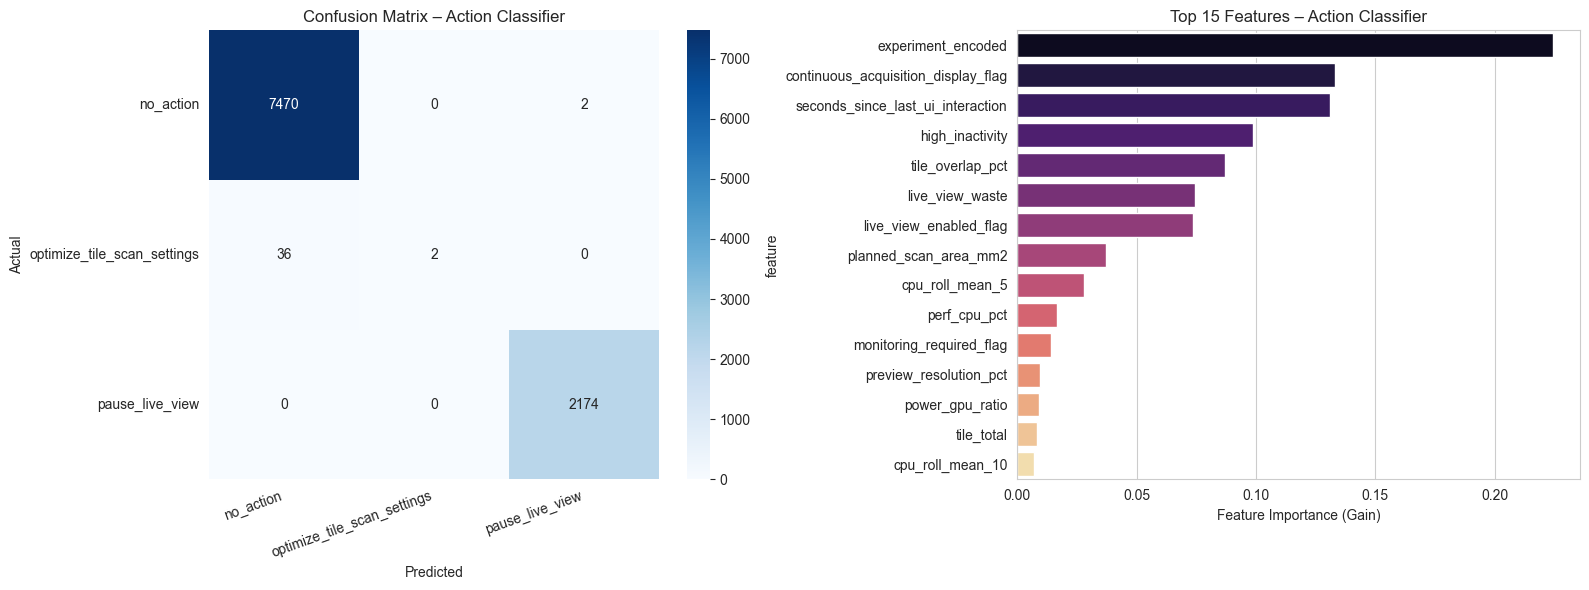

In [119]:
# ============================================================
# Cell 11: Classification – Confusion Matrix & Visualizations
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 11a. Confusion Matrix
ax = axes[0]
cm = confusion_matrix(y_test_cls, y_pred_action)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names,
            yticklabels=class_names, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix – Action Classifier')
plt.sca(ax); plt.xticks(rotation=20, ha='right'); plt.yticks(rotation=0)

# 11b. Feature Importance (Classification)
ax = axes[1]
clf_imp = pd.DataFrame({'feature': FEATURE_COLS, 'importance': clf_model.feature_importances_})
clf_imp = clf_imp.sort_values('importance', ascending=False).head(15)
sns.barplot(data=clf_imp, x='importance', y='feature', palette='magma', ax=ax)
ax.set_title('Top 15 Features – Action Classifier')
ax.set_xlabel('Feature Importance (Gain)')

plt.tight_layout()
plt.show()

## 6. Per-Scenario Analysis
Train and evaluate models per scenario to understand individual scenario patterns.

Per-Scenario Model Performance (Macro F1 = fair metric for imbalanced data):
Scenario                                                   Classes  Energy_R2  Energy_MAE  Action_Acc  Action_F1_macro  Rows
      S1 [no_action, optimize_tile_scan_settings, pause_live_view]     0.9997     0.00060         1.0              1.0  3228
     S10 [no_action, optimize_tile_scan_settings, pause_live_view]     0.9998     0.00108         1.0              1.0  3228
      S2                              [no_action, pause_live_view]     0.9952     0.00077         1.0              1.0  3228
      S3 [no_action, optimize_tile_scan_settings, pause_live_view]     0.9997     0.00051         1.0              1.0  3228
      S4                              [no_action, pause_live_view]     0.9987     0.00038         1.0              1.0  3228
      S5 [no_action, optimize_tile_scan_settings, pause_live_view]     0.9731     0.00719         1.0              1.0  3228
      S6                                        

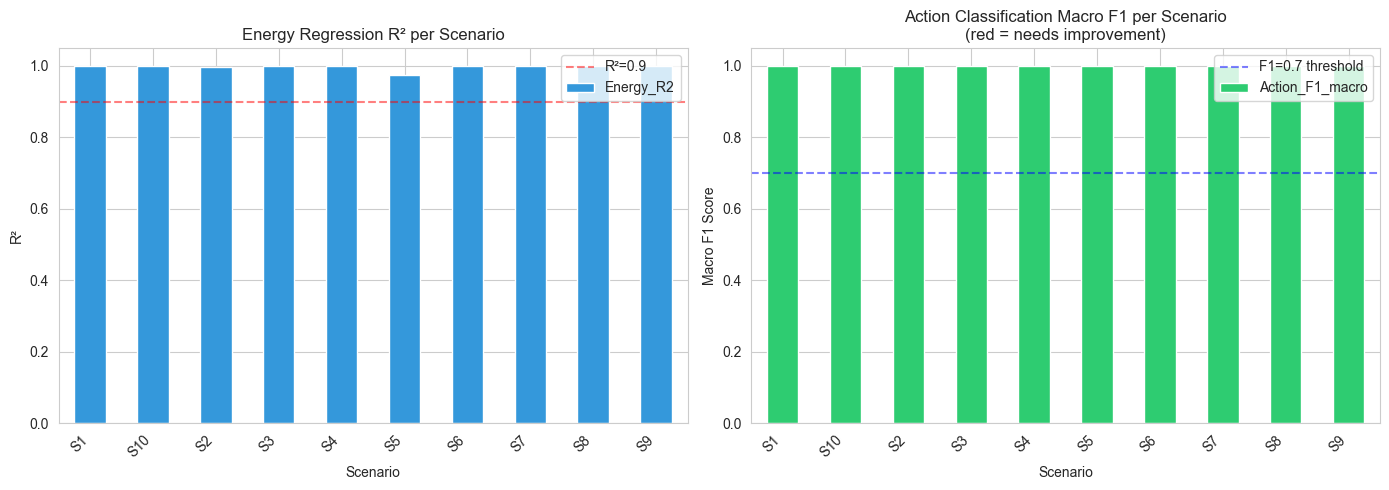

In [120]:
# ============================================================
# Cell 12: Per-Scenario Model Performance
# (with stratified split + SMOTE per scenario)
# ============================================================
# KEY FIX: Use a LOCAL LabelEncoder per scenario.
# The global `le` maps 3 classes → [0, 1, 2].
# If a scenario only has 2 of those 3 classes (e.g. [0, 2]),
# XGBoost raises ValueError because it requires contiguous labels
# starting at 0 (i.e. [0, 1] for 2 classes, not [0, 2]).
# A local encoder re-maps whatever classes are present → [0, 1, ...].
# ============================================================

scenario_results = []

for scenario_name, group in df_feat.groupby('scenario'):
    X_s = group[FEATURE_COLS].values
    y_s_energy = group[ENERGY_TARGET].values

    # Local encoder: ensures contiguous [0, 1, ...] for this scenario's classes
    local_le = LabelEncoder()
    y_s_action = local_le.fit_transform(group[ACTION_TARGET])
    local_classes = local_le.classes_

    if len(X_s) < 50:
        continue

    # ── Energy: 70/30 time-ordered split (temporal integrity) ──
    split = int(len(X_s) * 0.7)
    Xtr_e, Xte_e = X_s[:split], X_s[split:]
    ytr_e, yte_e = y_s_energy[:split], y_s_energy[split:]

    reg = xgb.XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05, n_jobs=-1)
    reg.fit(Xtr_e, ytr_e)
    pred_e = reg.predict(Xte_e)
    r2_s = r2_score(yte_e, pred_e)
    mae_s = mean_absolute_error(yte_e, pred_e)

    # ── Action: stratified split + SMOTE (imbalance fix) ──
    unique_actions, counts = np.unique(y_s_action, return_counts=True)

    if len(unique_actions) > 1:
        min_count = counts.min()
        if min_count >= 5:
            sss_s = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
            tr_idx, te_idx = next(sss_s.split(X_s, y_s_action))
            Xtr_a, Xte_a = X_s[tr_idx], X_s[te_idx]
            ytr_a, yte_a = y_s_action[tr_idx], y_s_action[te_idx]
        else:
            split_a = int(len(X_s) * 0.7)
            Xtr_a, Xte_a = X_s[:split_a], X_s[split_a:]
            ytr_a, yte_a = y_s_action[:split_a], y_s_action[split_a:]

        # SMOTE only if minority class has ≥ 6 samples in training
        tr_counts = np.bincount(ytr_a, minlength=len(local_classes))
        if tr_counts.min() >= 6:
            sm = SMOTE(random_state=42, k_neighbors=min(5, tr_counts.min() - 1))
            Xtr_a, ytr_a = sm.fit_resample(Xtr_a, ytr_a)

        clf = xgb.XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05, n_jobs=-1)
        clf.fit(Xtr_a, ytr_a)
        pred_a = clf.predict(Xte_a)
        acc_s = accuracy_score(yte_a, pred_a)
        f1_s = f1_score(yte_a, pred_a, average='macro', zero_division=0)
    else:
        acc_s = 1.0
        f1_s = 1.0

    scenario_results.append({
        'Scenario': scenario_name,
        'Classes': list(local_classes),
        'Energy_R2': round(r2_s, 4),
        'Energy_MAE': round(mae_s, 5),
        'Action_Acc': round(acc_s, 4),
        'Action_F1_macro': round(f1_s, 4),
        'Rows': len(X_s)
    })

results_df = pd.DataFrame(scenario_results)
print("Per-Scenario Model Performance (Macro F1 = fair metric for imbalanced data):")
print("=" * 90)
print(results_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
results_df.plot(x='Scenario', y='Energy_R2', kind='bar', ax=ax, color='#3498db', legend=False)
ax.set_title('Energy Regression R² per Scenario')
ax.set_ylabel('R²')
ax.axhline(y=0.9, color='red', linestyle='--', alpha=0.5, label='R²=0.9')
ax.legend()
plt.sca(ax); plt.xticks(rotation=45, ha='right')

ax = axes[1]
colors = ['#e74c3c' if v < 0.7 else '#2ecc71' for v in results_df['Action_F1_macro']]
results_df.plot(x='Scenario', y='Action_F1_macro', kind='bar', ax=ax,
                color=colors, legend=False)
ax.set_title('Action Classification Macro F1 per Scenario\n(red = needs improvement)')
ax.set_ylabel('Macro F1 Score')
ax.axhline(y=0.7, color='blue', linestyle='--', alpha=0.5, label='F1=0.7 threshold')
ax.legend()
plt.sca(ax); plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

## 7. Efficient Phase Reference Profiles (CORE HACKATHON DELIVERABLE)

The hackathon requires us to:
1. **Learn what efficient phases look like** from training scenarios
2. **Compare S13 phase-by-phase** against those references
3. **Propose improvements** based on deviations

### Which scenarios are "efficient"?
From the scenario descriptions:
- **S2** (Low Energy Deferred Batch) → low power, live view off
- **S3** (Frequent Short Scans) → efficient tile settings, low overlap
- **S8** (Post Acquisition Reconstruction) → live view correctly off during processing

### Approach
For each of the 4 phases, we compute reference thresholds from the best-performing scenarios and the overall training distribution.

Per-Scenario Phase Profiles:
scenario        workflow_phase  mean_power  live_view_pct  mean_overlap  mean_energy
      S1                  idle     178.018          0.000         0.000        0.742
      S1  live_view_monitoring     223.884          1.000         0.000        0.933
      S1            processing     257.984          0.747        19.880        1.075
      S1 tile_scan_acquisition     260.876          1.000        20.034        1.087
     S10                  idle     143.644          0.226         0.000        0.599
     S10  live_view_monitoring     188.421          1.000         0.000        0.785
     S10            processing     208.716          0.153         0.000        0.870
     S10 tile_scan_acquisition     213.511          1.000         9.945        0.890
     S13                  idle     141.287          0.509         0.000        0.589
     S13  live_view_monitoring     180.536          1.000         0.000        0.752
     S13            processing     2

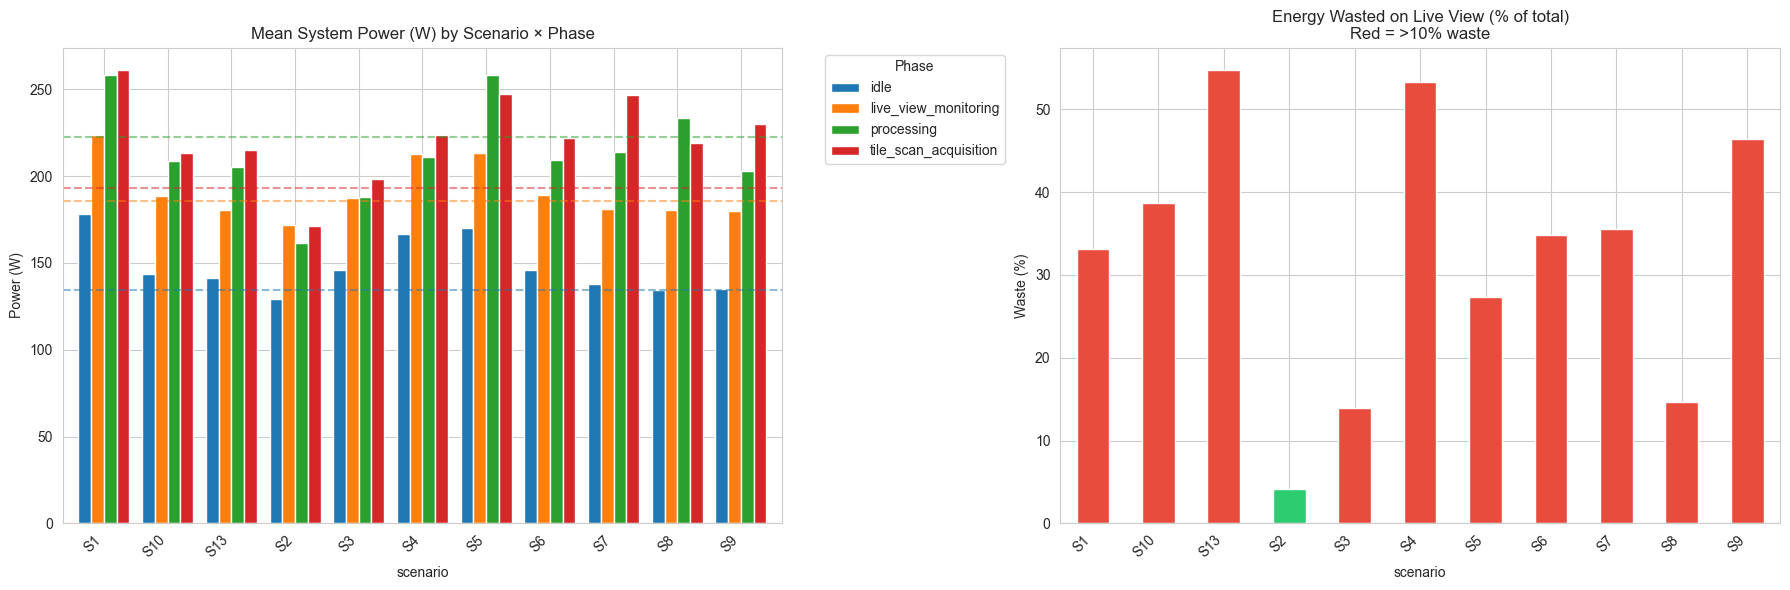


⚡ Energy waste from live view (ON + no interaction + >60s idle):
scenario
S1     1125.100
S10     885.068
S13    1445.317
S2       79.047
S3      336.918
S4     1544.840
S5      833.067
S6      932.567
S7     1019.347
S8      397.412
S9     1076.207


In [121]:
# ============================================================
# Cell 13: Build Efficient Phase Reference Profiles
# ============================================================

# ── 13a. Per-scenario per-phase profiles ─────────────────────
phase_profiles = df.groupby(['scenario', 'workflow_phase']).agg(
    mean_power=('estimated_system_power_w', 'mean'),
    std_power=('estimated_system_power_w', 'std'),
    total_energy=('estimated_energy_wh_interval', 'sum'),
    mean_energy=('estimated_energy_wh_interval', 'mean'),
    rows=('estimated_energy_wh_interval', 'count'),
    live_view_pct=('live_view_enabled_flag', 'mean'),
    user_interact_pct=('user_interacting_flag', 'mean'),
    mean_gpu_power=('perf_gpu_power_w', 'mean'),
    mean_cpu=('perf_cpu_pct', 'mean'),
    mean_overlap=('tile_overlap_pct', 'mean'),
    mean_scan_area=('planned_scan_area_mm2', 'mean'),
    mean_inactivity=('seconds_since_last_ui_interaction', 'mean'),
    tile_x_max=('tile_count_x', 'max'),
    tile_y_max=('tile_count_y', 'max'),
).round(3).reset_index()

print("Per-Scenario Phase Profiles:")
print(phase_profiles[['scenario', 'workflow_phase', 'mean_power',
                       'live_view_pct', 'mean_overlap', 'mean_energy']].to_string(index=False))

# ── 13b. Identify efficient reference scenarios ──────────────
# Efficient = lowest mean power per phase across scenarios
# Based on scenario docs:
#   S2 (low energy deferred batch) - efficient power usage
#   S3 (frequent short scans) - low overlap, small area
#   S8 (post acquisition reconstruction) - live view off during processing
EFFICIENT_SCENARIOS = ['S2', 'S3', 'S8']

# ── 13c. Build EFFICIENT REFERENCE per phase ─────────────────
# For each phase: take 25th percentile of power from ALL training as "efficient" threshold
# AND compute metrics from efficient scenarios specifically
efficient_ref = {}
all_phases = ['tile_scan_acquisition', 'live_view_monitoring', 'processing', 'idle']

print("\n" + "=" * 80)
print("EFFICIENT PHASE REFERENCE PROFILES")
print("=" * 80)

for phase in all_phases:
    phase_data = df[df['workflow_phase'] == phase]
    eff_data = df[(df['workflow_phase'] == phase) & (df['scenario'].isin(EFFICIENT_SCENARIOS))]

    ref = {
        'phase': phase,
        # Overall training statistics
        'all_mean_power': round(phase_data['estimated_system_power_w'].mean(), 2),
        'all_median_power': round(phase_data['estimated_system_power_w'].median(), 2),
        'all_p25_power': round(phase_data['estimated_system_power_w'].quantile(0.25), 2),
        'all_p75_power': round(phase_data['estimated_system_power_w'].quantile(0.75), 2),
        'all_mean_energy': round(phase_data['estimated_energy_wh_interval'].mean(), 5),
        # Efficient scenario benchmarks
        'eff_mean_power': round(eff_data['estimated_system_power_w'].mean(), 2) if len(eff_data) > 0 else None,
        'eff_mean_energy': round(eff_data['estimated_energy_wh_interval'].mean(), 5) if len(eff_data) > 0 else None,
        # Behavioral thresholds
        'eff_live_view_pct': round(eff_data['live_view_enabled_flag'].mean(), 3) if len(eff_data) > 0 else None,
        'eff_user_interact_pct': round(eff_data['user_interacting_flag'].mean(), 3) if len(eff_data) > 0 else None,
        'eff_mean_overlap': round(eff_data['tile_overlap_pct'].mean(), 2) if len(eff_data) > 0 else None,
        'eff_mean_gpu': round(eff_data['perf_gpu_power_w'].mean(), 2) if len(eff_data) > 0 else None,
        # Deviation thresholds (flag if test scenario exceeds these)
        'power_warning_threshold': round(phase_data['estimated_system_power_w'].quantile(0.75), 2),
        'live_view_waste_threshold': 0.3,  # if >30% live view with no interaction → flag
        'overlap_warning_threshold': 15.0,  # if overlap > 15% → flag for optimization
    }
    efficient_ref[phase] = ref

    print(f"\n{'─' * 60}")
    print(f"Phase: {phase}")
    print(f"{'─' * 60}")
    print(f"  Training avg power:     {ref['all_mean_power']} W")
    print(f"  Training P25-P75 power: {ref['all_p25_power']} – {ref['all_p75_power']} W")
    print(f"  Efficient ref power:    {ref['eff_mean_power']} W  (from {EFFICIENT_SCENARIOS})")
    if ref['eff_live_view_pct'] is not None:
        print(f"  Efficient live view %:  {ref['eff_live_view_pct']*100:.1f}%")
        print(f"  Efficient overlap %:    {ref['eff_mean_overlap']}%")
    print(f"  Power warning at:       > {ref['power_warning_threshold']} W")

# ── 13d. Visualization ───────────────────────────────────────
pivot = phase_profiles.pivot_table(index='scenario', columns='workflow_phase',
                                    values='mean_power', fill_value=0)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

ax = axes[0]
pivot.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Mean System Power (W) by Scenario × Phase')
ax.set_ylabel('Power (W)')
# Add efficient reference lines
for i, phase in enumerate(pivot.columns):
    if phase in efficient_ref and efficient_ref[phase]['eff_mean_power']:
        ax.axhline(y=efficient_ref[phase]['eff_mean_power'], color=f'C{i}',
                   linestyle='--', alpha=0.5)
ax.legend(title='Phase', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.sca(ax); plt.xticks(rotation=45, ha='right')

ax = axes[1]
# Live view waste by scenario
waste = df[(df['live_view_enabled_flag'] == True) &
           (df['user_interacting_flag'] == False) &
           (df['seconds_since_last_ui_interaction'] > 60)]
waste_energy = waste.groupby('scenario')['estimated_energy_wh_interval'].sum()
total_energy = df.groupby('scenario')['estimated_energy_wh_interval'].sum()
waste_pct = (waste_energy / total_energy * 100).fillna(0).round(1)
colors = ['#e74c3c' if v > 10 else '#2ecc71' for v in waste_pct]
waste_pct.plot(kind='bar', ax=ax, color=colors)
ax.set_title('Energy Wasted on Live View (% of total)\nRed = >10% waste')
ax.set_ylabel('Waste (%)')
plt.sca(ax); plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("\n⚡ Energy waste from live view (ON + no interaction + >60s idle):")
print(waste_energy.round(3).to_string())

## 8. Save Trained Models & Export Results

In [122]:
# ============================================================
# Cell 14: Save models, configs & efficient reference profiles
# ============================================================
import json, pickle

MODEL_DIR = Path('..') / '..' / 'src' / 'models'
MODEL_DIR.mkdir(exist_ok=True)

# Save XGBoost models
reg_model.save_model(str(MODEL_DIR / 'energy_regressor.json'))
clf_model.save_model(str(MODEL_DIR / 'action_classifier.json'))

# Save label encoder
with open(MODEL_DIR / 'label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

# Save model config
config = {
    'feature_columns': FEATURE_COLS,
    'energy_target': ENERGY_TARGET,
    'action_target': ACTION_TARGET,
    'class_names': list(class_names),
    'phase_map': {'idle': 0, 'processing': 1, 'live_view_monitoring': 2, 'tile_scan_acquisition': 3},
    'experiment_map': {'none': 0, 'alignment_check': 1, 'overview_scan': 2, 'tile_scan': 3,
                       'time_lapse': 4, 'reconstruction_only': 5},
    'quality_map': {'low': 0, 'medium': 1, 'high': 2}
}
with open(MODEL_DIR / 'model_config.json', 'w') as f:
    json.dump(config, f, indent=2)

# Save phase profiles (per-scenario)
phase_profiles.to_csv(MODEL_DIR / 'phase_profiles.csv', index=False)

# Save EFFICIENT REFERENCE PROFILES (core hackathon deliverable)
with open(MODEL_DIR / 'efficient_reference.json', 'w') as f:
    json.dump(efficient_ref, f, indent=2)

print(f"Models & references saved to: {MODEL_DIR.resolve()}")
print(f"  • energy_regressor.json     (XGBoost energy model)")
print(f"  • action_classifier.json    (XGBoost action model)")
print(f"  • label_encoder.pkl         (action label encoder)")
print(f"  • model_config.json         (feature list & mappings)")
print(f"  • phase_profiles.csv        (per-scenario phase stats)")
print(f"  • efficient_reference.json  (phase efficiency benchmarks)")
print(f"\nEfficient reference derived from: {EFFICIENT_SCENARIOS}")

Models & references saved to: C:\Users\dxdel\Downloads\Workflow Optimisation(Energy)_starter_kit_without_test\Workflow Optimisation(Energy)_starter_kit_with_data\Workflow Optimisation(Energy)_starter_kit_with_data\src\models
  • energy_regressor.json     (XGBoost energy model)
  • action_classifier.json    (XGBoost action model)
  • label_encoder.pkl         (action label encoder)
  • model_config.json         (feature list & mappings)
  • phase_profiles.csv        (per-scenario phase stats)
  • efficient_reference.json  (phase efficiency benchmarks)

Efficient reference derived from: ['S2', 'S3', 'S8']


## 9. Inference Helper – Predict on New Data

In [123]:
# ============================================================
# Cell 15: Reusable prediction function
# ============================================================

def predict_energy_and_action(csv_path):
    """Load a new scenario CSV and predict energy + recommended action."""
    new_df = pd.read_csv(csv_path)
    new_df['timestamp'] = pd.to_datetime(new_df['timestamp'])
    new_df['scenario'] = 'NEW'
    new_df = new_df.sort_values('timestamp').reset_index(drop=True)
    
    # Feature engineering
    new_feat = create_features(new_df)
    new_feat = new_feat.dropna().reset_index(drop=True)
    
    # Load models
    reg = xgb.XGBRegressor()
    reg.load_model(str(MODEL_DIR / 'energy_regressor.json'))
    clf = xgb.XGBClassifier()
    clf.load_model(str(MODEL_DIR / 'action_classifier.json'))
    
    with open(MODEL_DIR / 'label_encoder.pkl', 'rb') as f:
        le_loaded = pickle.load(f)
    
    X_new = new_feat[FEATURE_COLS].values
    
    # Predictions
    energy_pred = reg.predict(X_new)
    action_pred = le_loaded.inverse_transform(clf.predict(X_new))
    
    new_feat['predicted_energy_wh'] = energy_pred
    new_feat['predicted_action'] = action_pred
    
    # Summary
    print(f"Scenario: {csv_path}")
    print(f"Rows processed: {len(new_feat)}")
    print(f"\nPredicted Action Distribution:")
    print(new_feat['predicted_action'].value_counts().to_string())
    print(f"\nPredicted Energy Stats:")
    print(new_feat['predicted_energy_wh'].describe().round(4).to_string())
    
    return new_feat

# Example usage (uncomment to run on test data):
# result = predict_energy_and_action('../../data/test/S13_low_priority_screening_mode_v4.csv')
print("✅ Inference function ready. Use predict_energy_and_action('path/to/scenario.csv')")

✅ Inference function ready. Use predict_energy_and_action('path/to/scenario.csv')


## 10. Summary

| Model | Task | Algorithm | Key Metric |
|-------|------|-----------|------------|
| Energy Regressor | Predict `estimated_energy_wh_interval` | XGBoost Regressor | R², MAE, RMSE |
| Action Classifier | Predict `recommended_action` | XGBoost Classifier | Accuracy, F1 (macro/weighted) |

### Features Used (Rob Mulla Style):
- **Time features**: hour, minute, dayofweek, elapsed_sec
- **Lag features**: energy & power lags at 1, 2, 3, 5, 10 steps
- **Rolling stats**: mean & std for energy, power, GPU, CPU over windows of 5, 10, 20
- **Domain features**: tile_total, live_view_waste, high_inactivity, power_gpu_ratio, total_data_throughput, energy_delta, phase_duration
- **Encoded categoricals**: workflow_phase, experiment_type, quality_constraint